In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

def literal_eval(cadena):
  if cadena and type(cadena) == str:
    return ast.literal_eval(cadena)
  return cadena

df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(literal_eval)

df.sort_values(by="job_posted_date", inplace = True)


In [ ]:
df = df[df["job_title_short"]=="Data Analyst"]

df["month"] = df["job_posted_date"].dt.strftime(format("%B"))
df_exploded = df.explode("job_skills")
df_exploded = df_exploded.sort_values(by="job_posted_date")
df_exploded.reset_index(inplace=True)
df_exploded.set_index("month", inplace=True)

In [ ]:
top_skills = df_exploded["job_skills"].value_counts().head(6).index.to_list()
top_skills

['sql', 'excel', 'python', 'tableau', 'power bi', 'r']

In [ ]:
df_top_skills = df_exploded[(df_exploded["job_skills"].isin(top_skills))]

In [ ]:
df_pivot = df_top_skills.pivot_table(
    index=df_top_skills.index,
    columns="job_skills",
    aggfunc="size",
    sort=False
)

In [ ]:
skill_stats = df_exploded.groupby("job_skills").agg(
    skill_count = ("job_skills", "count"),
    skill_pay = ("salary_year_avg", "median")
)

scatter_table =skill_stats.sort_values(by="skill_count", ascending=False).head(20)
scatter_table

,skill_count,skill_pay
job_skills,,
sql,92428,92500.000000
excel,66860,84479.000000
python,57190,98500.000000
tableau,46455,95000.000000
power bi,39380,90000.000000
r,29996,92527.500000
sas,27998,90000.000000
powerpoint,13822,85000.000000
word,13562,80000.000000


<Axes: xlabel='month'>

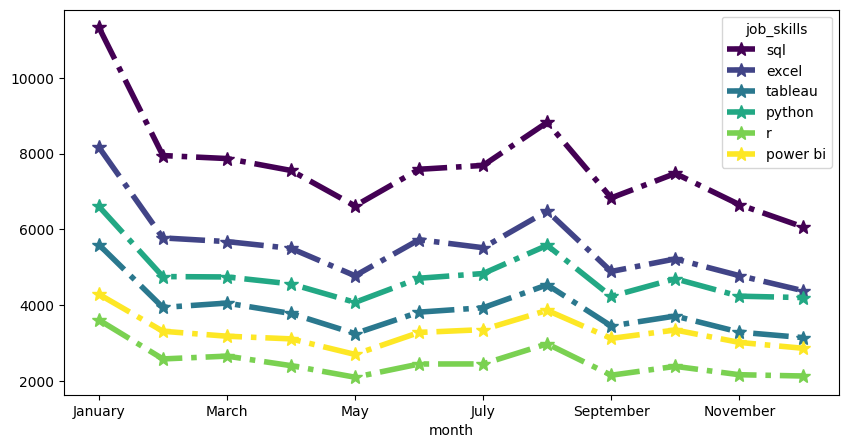

In [ ]:
df_pivot.plot(
    kind="line",
    linewidth = 4,
    linestyle = "-.", # options: '-', '--', '-.', ':', 'None', 'solid', 'dashed', 'dashdot', 'dotted'
    colormap= "viridis", # options: "jet", viridis", "plasma", "magma", "inferno", "cividis"
    marker = "*", # options: "o", "x", "+", "*", "s", ",", ".", "1", "2", "3", "4"
    markersize= 10,
    figsize=(10, 5)
)

<Axes: title={'center': 'January vs February'}, xlabel='Month', ylabel='Count'>

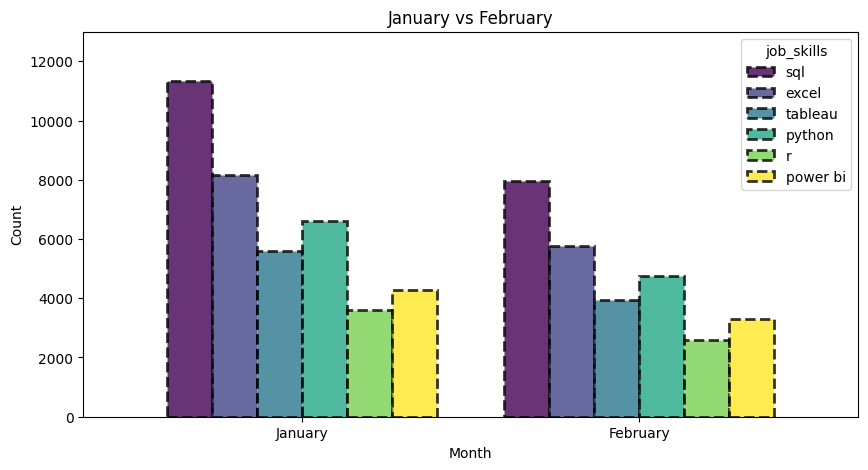

In [ ]:
df_pivot[df_pivot.index.isin(["January", "February"])].plot(
    kind="bar",

    # Tamaño de las barras
    width=0.8,              # ancho de las barras

    # Colores
    colormap="viridis",     # "jet", "viridis", "plasma", "magma",
                            # "inferno", "cividis"

    # Bordes de las barras
    edgecolor="black",      # color del borde
    linewidth=2,            # grosor del borde
    linestyle="--",         # "-", "--", "-.", ":"

    # Transparencia
    alpha=0.8,              # 0 = transparente, 1 = completamente visible

    # Distribución
    stacked=False,          # True = barras apiladas

    # Tamaño de la gráfica
    figsize=(10, 5),

    # Ejes
    ylim=(0, 13000),       # (mínimo, máximo)

    # Labels
    xlabel="Month",
    ylabel="Count",
    title="January vs February",

    # Otros
    rot=0,                  # rotación de los labels del eje X
    grid=False,
    legend=True
)

In [ ]:
!pip install adjustText
from adjustText import adjust_text

/tmp/ipykernel_2766/2604545415.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  texts.append(plt.text(scatter_table["skill_count"][i]+1000, scatter_table["skill_pay"][i], txt))


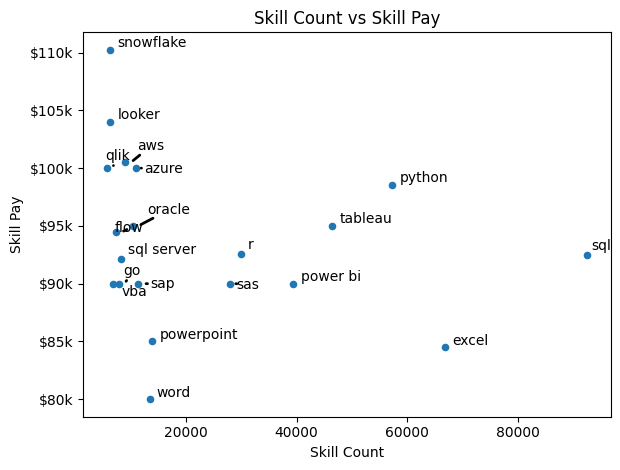

In [ ]:
# No es fácil decirle a matplotlib que muestre los nombres, se puede usar annotate o text(coordenadax, coordenaday, texto)

# fig, ax = plt.subplots()

scatter_table.plot(kind="scatter", x = "skill_count", y = "skill_pay")
plt.xlabel("Skill Count")
plt.ylabel("Skill Pay")
plt.title("Skill Count vs Skill Pay")
plt.tight_layout()

# for i, txt in enumerate(scatter_table.index):
#   plt.annotate(txt, (scatter_table["skill_count"][i]+1000, scatter_table["skill_pay"][i]))

texts = []

for i, txt in enumerate(scatter_table.index):
  texts.append(plt.text(scatter_table["skill_count"][i]+1000, scatter_table["skill_pay"][i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle="-", color="black", lw=2))

ax = plt.gca() # get current axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k'))

plt.show()